# Mínimos cuadrados y proyecciones

**Departamento de Ciencias Físicas, Exactas & Energía / FIDCA**

<!--
Copyright © Angela Villota y Aníbal Sosa.

El contenido textual está licenciado bajo Creative Commons
Attribution-NonCommercial 4.0 International (CC BY-NC 4.0).

El código y la lógica de los notebooks están licenciados bajo
PolyForm Noncommercial License 1.0.0.

Consulte el archivo LICENSE del repositorio para conocer los términos completos.
-->

**Lecturas sugeridas**: Capítulo  12 del libro de Boyd and Vanderberghe(2018).

**<u>Agenda</u>**
* **El problema de mínimos cuadrados**
* **Solución del problema de mínimos cuadrados.**
---

## **Matemáticas Aplicadas III**
#### **Cuaderno 6: Mínimos Cuadrados ($A\mathbf{x} \approx \mathbf{b}$)**

**Lecturas sugeridas**: Capítulo 12 del libro de *Boyd and Vandenberghe (2018)*.

---

## **1. Sistemas de Ecuaciones Lineales sin Solución**

Muchos problemas del mundo real nos llevan a sistemas de ecuaciones lineales que carecen de una solución exacta, lo cual es el escenario usual en los sistemas **sobredeterminados** ($m > n$).

En estos casos, el objetivo cambia: ya no buscamos una solución exacta, sino la **mejor solución posible** $\mathbf{\hat{x}}$ en el sentido geométrico. El método de mínimos cuadrados selecciona un vector $\mathbf{\hat{x}}$ de tal manera que la norma del error al cuadrado sea lo más pequeña posible:

$$\min_{\mathbf{x}} \|A\mathbf{x} - \mathbf{b}\|^2$$

Es decir, se minimiza la suma de los residuos o errores en cada una de las ecuaciones. Este método fue descubierto de forma independiente por los matemáticos *Carl Friedrich Gauss* y *Adrien-Marie Legendre* en el siglo XIX.

---

## **2. Enfoque Geométrico del Problema**

Afirmar que el sistema $A\mathbf{x} = \mathbf{b}$ no tiene solución es equivalente a decir que el vector de datos $\mathbf{b}$ **no pertenece al espacio columna de $A$** ($\mathbf{b} \notin C(A)$).

Por lo tanto, buscamos un vector de proyección $\mathbf{p} = A\mathbf{x}^*$ tal que $\mathbf{p}$ pertenezca a $C(A)$ y se encuentre a la mínima distancia posible de $\mathbf{b}$.

Para analizar este problema geométricamente, consideraremos el sistema con la siguiente matriz y vector:

$$A = \begin{bmatrix} 1 & 1 \\ 1 & 0 \\ 1 & -1 \end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix} 2 \\ -1 \\ 2 \end{bmatrix}$$

In [ ]:
#@title Vector de proyección { display-mode: "form" }
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/gjbn9c35",
  width="1020px",
  height="480px"
)
IP.display_html(iframe)

### **Preguntas de Reflexión (Ejercicio en el Applet)**

1. ¿A qué espacio vectorial pertenece el vector $A\mathbf{x}$ por definición? Verifica tu respuesta eligiendo algunos vectores $\mathbf{x}$ arbitrarios y grafícalos en el applet.
2. Encuentra el vector residual $A\mathbf{x} - \mathbf{b}$ para tus elecciones anteriores. ¿Qué significa geométricamente hallar un vector $\mathbf{x}^*$ tal que $A\mathbf{x}^* - \mathbf{b}$ sea lo más pequeño posible?
3. Geométricamente, ¿qué propiedad de ortogonalidad debe cumplir el vector de error $A\mathbf{x}^* - \mathbf{b}$ con respecto al espacio columna de $A$? ¿A qué subespacio fundamental de $A$ debe pertenecer dicho error?

## **3. Ecuaciones Normales: $A^TA\mathbf{x}^* = A^T\mathbf{b}$**

La condición geométrica de que el error $r = A\mathbf{x}^* - \mathbf{b}$ debe ser completamente perpendicular a las columnas de $A$ implica que $A^T(A\mathbf{x}^* - \mathbf{b}) = \mathbf{0}$. Al distribuir los términos, obtenemos el célebre **Sistema de Ecuaciones Normales**:

$$A^TA\mathbf{x}^* = A^T\mathbf{b}$$

Si las columnas de $A$ son linealmente independientes, la matriz cuadrada $A^TA$ es invertible y la única solución analítica al problema está dada por:

$$\mathbf{x}^* = (A^TA)^{-1}A^T\mathbf{b}$$

---

## **4. Estabilización Numérica mediante Factorización $QR$**

Calcular directamente la inversa de $A^TA$ es numéricamente inestable si la matriz está cerca de ser singular. Una alternativa mucho más robusta consiste en emplear la descomposición $A = QR$ (donde $Q$ es ortogonal y $R$ es triangular superior):

$$\begin{aligned}
\mathbf{x}^* &= ((QR)^TQR)^{-1}(QR)^T\mathbf{b} \\
&= (R^TQ^TQR)^{-1}R^TQ^T\mathbf{b} \\
&= (R^T I R)^{-1}R^TQ^T\mathbf{b} \\
&= R^{-1}(R^T)^{-1}R^TQ^T\mathbf{b} \\
&= R^{-1}Q^T\mathbf{b}
\end{aligned}$$

Esto reduce el problema a resolver el sistema triangular superior mediante sustitución hacia atrás:

$$R\mathbf{x}^* = Q^T\mathbf{b}$$

In [ ]:
# =====================================================================
# 5. Métodos de Solución para Mínimos Cuadrados
# =====================================================================
import numpy as np
from scipy import linalg

# Datos del problema original
A = np.array([[1, 1],
              [1, 0],
              [1, -1]])

b = np.array([2, -1, 0])

print("--- DATOS DEL SISTEMA ---")
print("A =\n", A)
print("b =", b, "\n")

# --- MÉTODO 1: Usando la función nativa lstsq ---
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print("--- SOLUCIÓN POR LSTSQ NATIVO ---")
print("x* =", x_lstsq)
print("Vector de proyección p = Ax* :", A.dot(x_lstsq), "\n")


# --- MÉTODO 2: Factorización QR con Sustitución Hacia Atrás ---
def backsubs(R, b_sub):
    """Algoritmo de sustitución hacia atrás para matrices triangulares superiores"""
    n = len(R[0])
    x_res = np.zeros(n)
    for i in range(n - 1, -1, -1):
        tmp = b_sub[i]
        for j in range(n - 1, i, -1):
            tmp -= x_res[j] * R[i, j]
        x_res[i] = tmp / R[i, i]
    return x_res

# Descomposición QR
Q, R = np.linalg.qr(A)
Qt = Q.transpose()
y = Qt.dot(b)

# Resolver R x = Q^T b
x_qr = backsubs(R, y)

print("--- SOLUCIÓN MEDIANTE FACTORIZACIÓN QR ---")
print("Matriz Q =\n", Q)
print("Matriz R =\n", R)
print("x* (Calculado por QR) =", x_qr)
print("Vector de proyección p = Ax* :", A.dot(x_qr))

--- DATOS DEL SISTEMA ---
A =
 [[ 1  1]
 [ 1  0]
 [ 1 -1]]
b = [ 2 -1  0] 

--- SOLUCIÓN POR LSTSQ NATIVO ---
x* = [0.33333333 1.        ]
Vector de proyección p = Ax* : [ 1.33333333  0.33333333 -0.66666667] 

--- SOLUCIÓN MEDIANTE FACTORIZACIÓN QR ---
Matriz Q =
 [[-5.77350269e-01  7.07106781e-01]
 [-5.77350269e-01  5.55111512e-17]
 [-5.77350269e-01 -7.07106781e-01]]
Matriz R =
 [[-1.73205081  0.        ]
 [ 0.          1.41421356]]
x* (Calculado por QR) = [0.33333333 1.        ]
Vector de proyección p = Ax* : [ 1.33333333  0.33333333 -0.66666667]


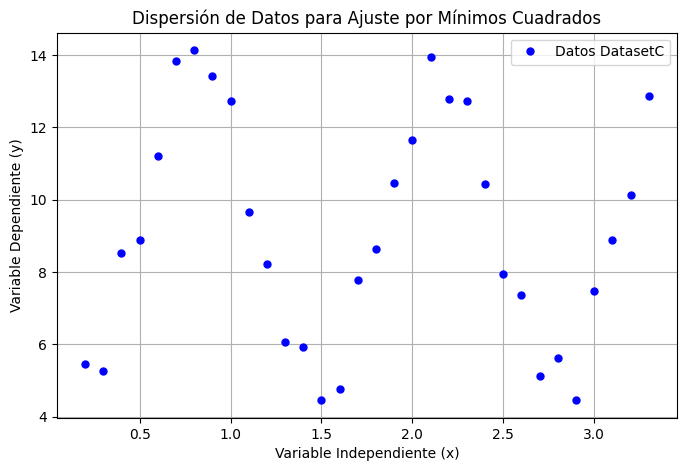

In [ ]:
# =====================================================================
# 6. Carga y Graficación de Datasets de Prueba
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt

# URLs base del repositorio de datos externos
URL1 = 'https://raw.githubusercontent.com/NumericalMethodsSullivan'
URL2 = '/NumericalMethodsSullivan.github.io/master/data/'
URL_COMPLETA = URL1 + URL2

try:
    # Carga de los diferentes conjuntos de datos
    datasetA = np.array(pd.read_csv(URL_COMPLETA + 'Exercise3_datafit2.csv'))
    datasetB = np.array(pd.read_csv(URL_COMPLETA + 'Exercise3_datafit3.csv'))
    datasetC = np.array(pd.read_csv(URL_COMPLETA + 'Exercise3_datafit4.csv'))

    # Graficación del dataset C como ejemplo de curvas para ajuste
    plt.figure(figsize=(8, 5))
    plt.plot(datasetC[:, 0], datasetC[:, 1], 'bo', markersize=5, label='Datos DatasetC')
    plt.title('Dispersión de Datos para Ajuste por Mínimos Cuadrados')
    plt.xlabel('Variable Independiente (x)')
    plt.ylabel('Variable Dependiente (y)')
    plt.grid(True)
    plt.legend()
    plt.show()

except Exception as e:
    print("Nota: Hubo un problema al conectar con el servidor de datos de Sullivan. Detalles:", e)